# Coágulos de sangre 13 veces más resistentes que el natural

> **5 días después de una lesión hepática, el coágulo estándar regenera el 20% del tejido. El coágulo nuevo: 78%.**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-29-engineering-tough-blood-clots/notebook.ipynb)

**Paper:** [Engineering tough blood clots for rapid haemostasis and enhanced regeneration](https://doi.org/10.1038/s41586-026-10412-y) — *Nature*, 29 abril 2026
**Video:** [Pendiente]

## El problema

Un coágulo natural se forma despacio y es frágil. Cuando una hemorragia es grave, eso cuesta vidas.

La idea del paper es directa: tomar glóbulos rojos y **pegarlos entre sí** con un polímero (hialuronato — el mismo que tienes en la piel — modificado con un grupo químico que se activa con luz visible). El resultado se llama EBC (*engineered blood clot*) y se forma en segundos.

Aquí abrimos los datos de las tablas suplementarias del paper para ver qué tanto cambia el desenlace cuando ese coágulo se prueba en una lesión hepática real.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
DIA_FOCO = 5                    # día clínico que más nos interesa (5, 14 o 28)
COLOR_EBC = '#2563EB'           # azul CaM — el coágulo nuevo
COLOR_FLOSEAL = '#DC2626'       # rojo — el estándar clínico
COLOR_REFERENCIA = '#D97706'    # ámbar — referencias / umbrales
COLOR_SECUNDARIO = '#059669'    # verde — datos de soporte
FUENTE = 'Fuente: Jiang et al. (2026), Nature | Datos: Tablas S1-S3 del Supplementary Information'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar los 5 CSVs (transcritos del SI del paper)
liver = pd.read_csv('datos/liver_regeneration_quant.csv')
biomats = pd.read_csv('datos/biomaterials_comparison.csv', keep_default_na=False)
polymer_mw = pd.read_csv('datos/polymer_mw_hyaluronidase.csv')
polymer_sub = pd.read_csv('datos/polymer_substitution.csv')
mech = pd.read_csv('datos/mechanical_headline.csv')

print(f"Regeneración hepática:   {len(liver)} filas (EBC vs Floseal × 3 días)")
print(f"Biomateriales:           {len(biomats)} filas (incluye EBC + 13 controles)")
print(f"Polímero (HA-TZ) Mw:     {len(polymer_mw)} puntos en el tiempo")
print(f"Sustitución de tetrazina: {len(polymer_sub)} formulaciones")
print(f"Mecánicos (headline):    {len(mech)} propiedades (EBC vs coágulo nativo)")

Regeneración hepática:   6 filas (EBC vs Floseal × 3 días)
Biomateriales:           14 filas (incluye EBC + 13 controles)
Polímero (HA-TZ) Mw:     4 puntos en el tiempo
Sustitución de tetrazina: 3 formulaciones
Mecánicos (headline):    2 propiedades (EBC vs coágulo nativo)


## El primer dato

Aquí está.

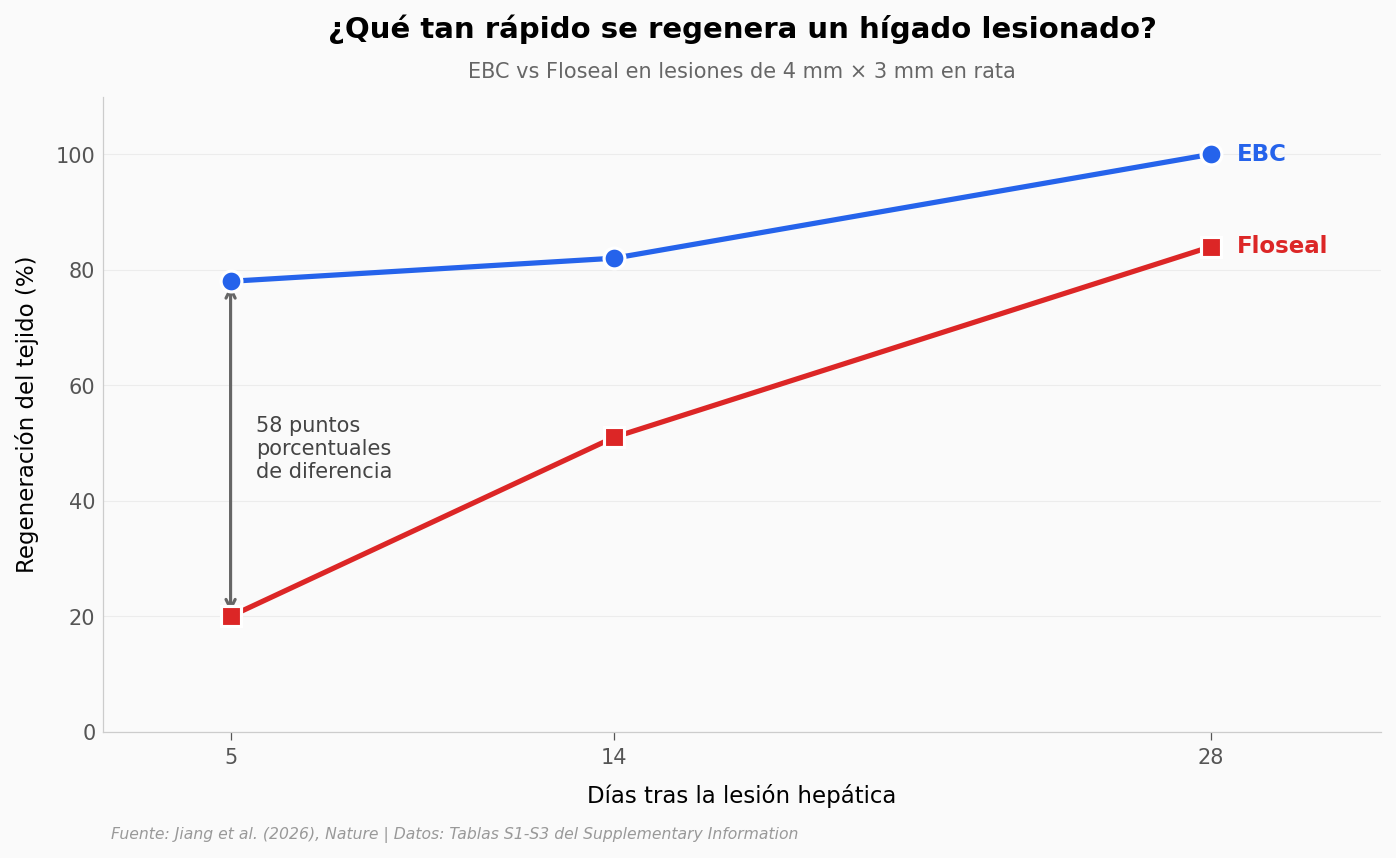

In [2]:
# Regeneración hepática EBC vs Floseal — días 5, 14, 28
fig, ax = plt.subplots(figsize=(11, 5.5))

ebc = liver[liver.biomaterial == 'EBC'].sort_values('day')
flo = liver[liver.biomaterial == 'Floseal'].sort_values('day')

ax.plot(ebc.day, ebc.regeneration_pct, 'o-', color=COLOR_EBC, linewidth=2.5,
        markersize=10, markeredgecolor='white', markeredgewidth=1.5, zorder=5,
        label='EBC (nuevo)')
ax.plot(flo.day, flo.regeneration_pct, 's-', color=COLOR_FLOSEAL, linewidth=2.5,
        markersize=10, markeredgecolor='white', markeredgewidth=1.5, zorder=5,
        label='Floseal (estándar)')

# Etiquetas inline (no legend box)
ax.text(28.6, 100, 'EBC', fontsize=11, fontweight='bold', color=COLOR_EBC, va='center')
ax.text(28.6, 84, 'Floseal', fontsize=11, fontweight='bold', color=COLOR_FLOSEAL, va='center')

# Anotar el gap del día 5 (el dato más fuerte)
ax.annotate('', xy=(5, 78), xytext=(5, 20),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(5.6, 49, '58 puntos\nporcentuales\nde diferencia',
        fontsize=10, color='#444444', va='center')

ax.set_xlabel('Días tras la lesión hepática', fontsize=11)
ax.set_ylabel('Regeneración del tejido (%)', fontsize=11)
ax.set_title('¿Qué tan rápido se regenera un hígado lesionado?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'EBC vs Floseal en lesiones de 4 mm × 3 mm en rata',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks([5, 14, 28])
ax.set_ylim(0, 110)
ax.set_xlim(2, 32)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/regeneracion_hepatica.png', dpi=200, bbox_inches='tight')
plt.show()

## Cómo leer esto

La ventaja del EBC se concentra en los primeros días. En el día 5 ya regeneró el 78% del tejido — el Floseal apenas empieza con un 20%. Cuando llegamos al día 28 los dos cierran la herida (100% vs 84%), pero la diferencia inicial cambia el escenario clínico: las primeras horas de una hemorragia son donde más vidas se pierden.

> **Nota sobre los datos:** la Tabla S3 del paper reporta un único valor por (biomaterial × día), estimado a partir de las imágenes histológicas. No hay desviación estándar ni n por celda, así que estos puntos son lecturas individuales — no medias con error. La tendencia es robusta porque los autores muestran imágenes consistentes, pero no podemos calcular Cohen's d aquí.

## ¿Y el polímero?

El EBC funciona porque un polímero (hialuronato — HA — modificado con tetrazina) une los glóbulos rojos en una red. La pregunta clínica obvia es: ¿se queda ese polímero en el tejido?

El equipo lo puso a digerir con hialuronidasa (la enzima que tu cuerpo usa para descomponer hialuronato) y midió cuánto duraba.

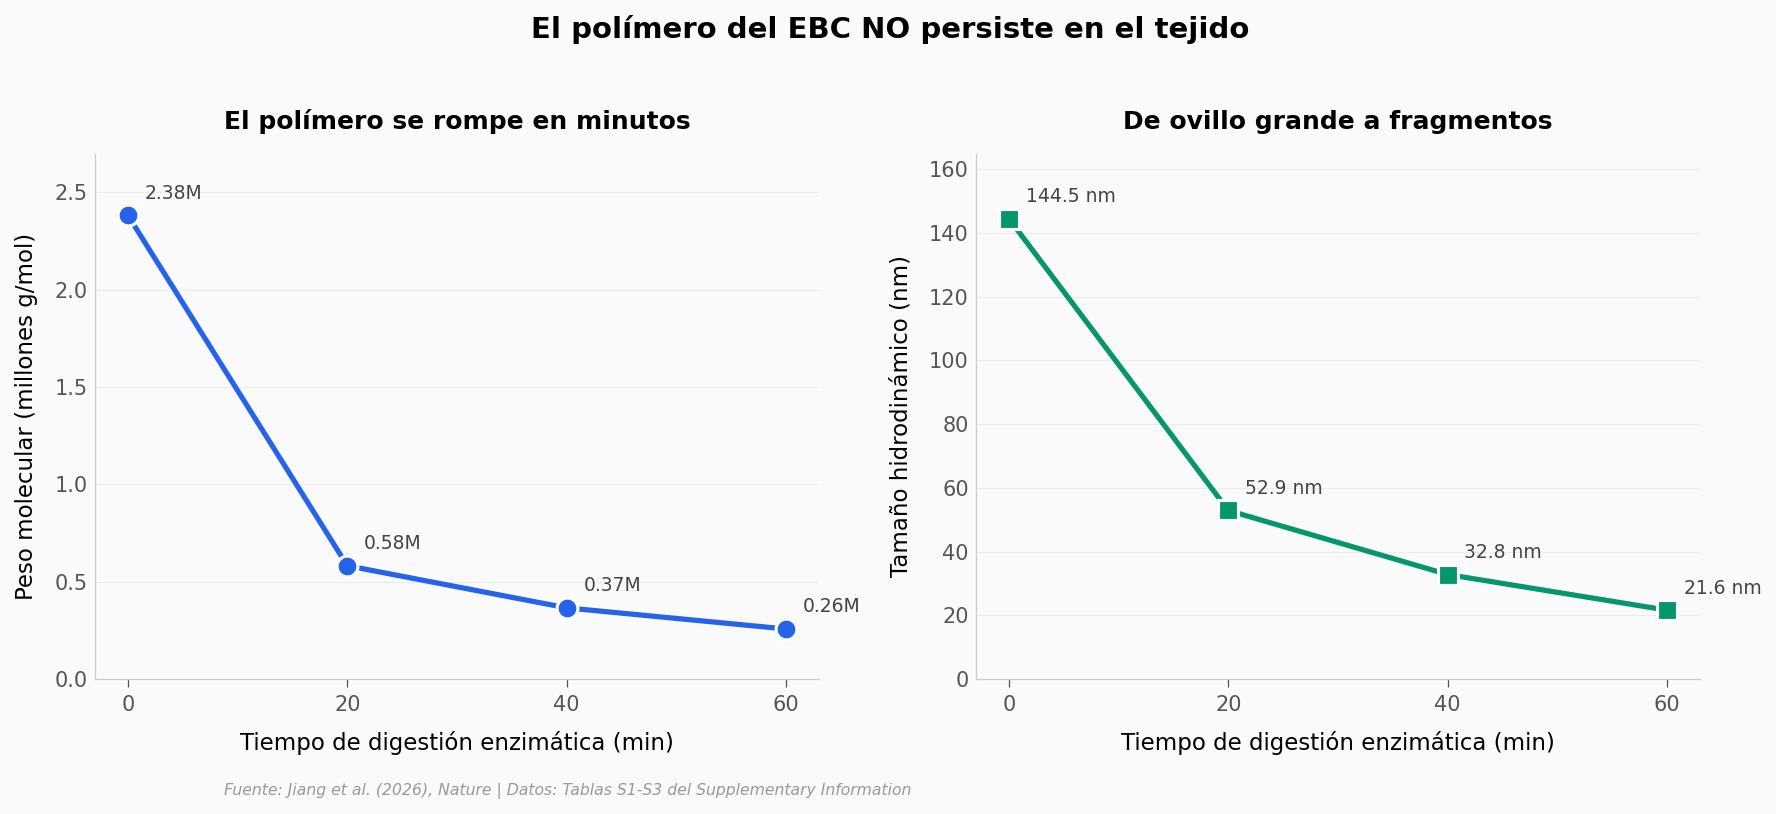


En 60 minutos de digestión:
  Peso molecular: 2.38M → 0.26M g/mol  (9.3× más pequeño)
  Tamaño cadena:  144.5 → 21.6 nm  (6.7× más pequeño)


In [3]:
# Mw del polímero HA-TZ vs tiempo con hialuronidasa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Eje izquierdo: Mw
ax1.plot(polymer_mw.hyaluronidase_min, polymer_mw.mw_g_per_mol / 1e6, 'o-',
         color=COLOR_EBC, linewidth=2.5, markersize=10,
         markeredgecolor='white', markeredgewidth=1.5)
for _, row in polymer_mw.iterrows():
    ax1.annotate(f"{row.mw_g_per_mol/1e6:.2f}M",
                 xy=(row.hyaluronidase_min, row.mw_g_per_mol/1e6),
                 xytext=(8, 8), textcoords='offset points',
                 fontsize=9, color='#444444')

ax1.set_xlabel('Tiempo de digestión enzimática (min)', fontsize=11)
ax1.set_ylabel('Peso molecular (millones g/mol)', fontsize=11)
ax1.set_title('El polímero se rompe en minutos',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xticks([0, 20, 40, 60])
ax1.set_ylim(0, 2.7)

# Eje derecho: tamaño hidrodinámico
ax2.plot(polymer_mw.hyaluronidase_min, polymer_mw.hydrodynamic_size_nm, 's-',
         color=COLOR_SECUNDARIO, linewidth=2.5, markersize=10,
         markeredgecolor='white', markeredgewidth=1.5)
for _, row in polymer_mw.iterrows():
    ax2.annotate(f"{row.hydrodynamic_size_nm:.1f} nm",
                 xy=(row.hyaluronidase_min, row.hydrodynamic_size_nm),
                 xytext=(8, 8), textcoords='offset points',
                 fontsize=9, color='#444444')

ax2.set_xlabel('Tiempo de digestión enzimática (min)', fontsize=11)
ax2.set_ylabel('Tamaño hidrodinámico (nm)', fontsize=11)
ax2.set_title('De ovillo grande a fragmentos',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_xticks([0, 20, 40, 60])
ax2.set_ylim(0, 165)

fig.suptitle('El polímero del EBC NO persiste en el tejido',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/polimero_decay.png', dpi=200, bbox_inches='tight')
plt.show()

# Cálculos del decaimiento
mw_inicial = polymer_mw.mw_g_per_mol.iloc[0]
mw_final = polymer_mw.mw_g_per_mol.iloc[-1]
size_inicial = polymer_mw.hydrodynamic_size_nm.iloc[0]
size_final = polymer_mw.hydrodynamic_size_nm.iloc[-1]
print(f"\nEn 60 minutos de digestión:")
print(f"  Peso molecular: {mw_inicial/1e6:.2f}M → {mw_final/1e6:.2f}M g/mol  ({mw_inicial/mw_final:.1f}× más pequeño)")
print(f"  Tamaño cadena:  {size_inicial:.1f} → {size_final:.1f} nm  ({size_inicial/size_final:.1f}× más pequeño)")

## Comparado con todo lo demás

El paper no se detiene ahí. Compara el EBC contra **13 biomateriales más** que se usan o se han propuesto para hemostasia y regeneración: Floseal, Surgicel, CoSeal, esponjas de gelatina, cianoacrilato, pegamentos inspirados en percebes…

Lo interesante es la columna de "respuesta a cuerpo extraño" — el rechazo crónico que tu sistema inmune monta contra material implantado.

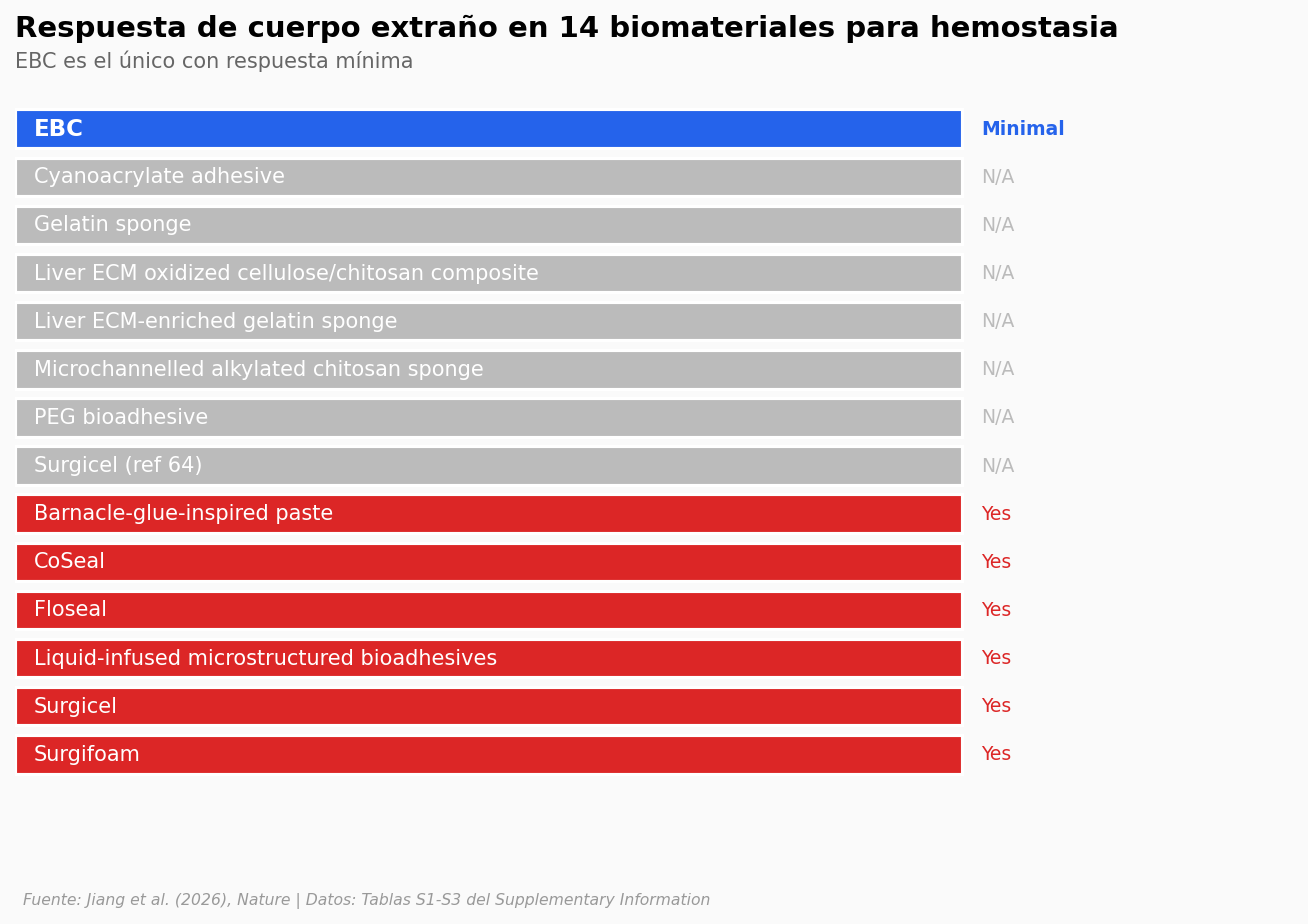


Respuesta a cuerpo extraño en los 14 biomateriales:
  N/A: 7
  Yes: 6
  Minimal: 1


In [4]:
# 14 biomateriales — clasificación de respuesta a cuerpo extraño (FBR)
fbr_order = {'Minimal': 0, 'N/A': 1, 'Yes': 2}
b = biomats.copy()
b['fbr_rank'] = b['foreign_body_response'].map(fbr_order)
b = b.sort_values(['fbr_rank', 'biomaterial']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))

color_map = {
    'Minimal': COLOR_EBC,        # solo EBC — destacado
    'Yes': COLOR_FLOSEAL,        # rechazo crónico
    'N/A': '#BBBBBB',            # sin reportar
}
colors = [color_map[v] for v in b.foreign_body_response]
bars = ax.barh(range(len(b)), [1]*len(b), color=colors, edgecolor='white', linewidth=1.5)

# Etiqueta del biomaterial dentro de la barra
for i, row in b.iterrows():
    is_ebc = row.biomaterial == 'EBC'
    ax.text(0.02, i, row.biomaterial,
            fontsize=10 if not is_ebc else 11,
            fontweight='bold' if is_ebc else 'normal',
            color='white', va='center', ha='left')
    # Etiqueta de FBR a la derecha
    ax.text(1.02, i, row.foreign_body_response,
            fontsize=9, color=color_map[row.foreign_body_response],
            fontweight='bold' if row.foreign_body_response == 'Minimal' else 'normal',
            va='center', ha='left')

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 1.35)
ax.set_ylim(-0.7, len(b) - 0.3)
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Respuesta de cuerpo extraño en 14 biomateriales para hemostasia',
             fontsize=14, fontweight='bold', pad=28, loc='left')
ax.text(0, 1.04, 'EBC es el único con respuesta mínima',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='left')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/biomateriales_fbr.png', dpi=200, bbox_inches='tight')
plt.show()

# Conteo
counts = biomats.foreign_body_response.value_counts()
print(f"\nRespuesta a cuerpo extraño en los 14 biomateriales:")
for k, v in counts.items():
    print(f"  {k}: {v}")

## ¿Qué tan inusual es?

De los 14 biomateriales comparados, **solo el EBC** logra una respuesta de cuerpo extraño mínima. Los otros 6 con datos publicados generan rechazo, y 7 ni siquiera reportan ese parámetro. En la métrica de regeneración, el contraste también se ve.

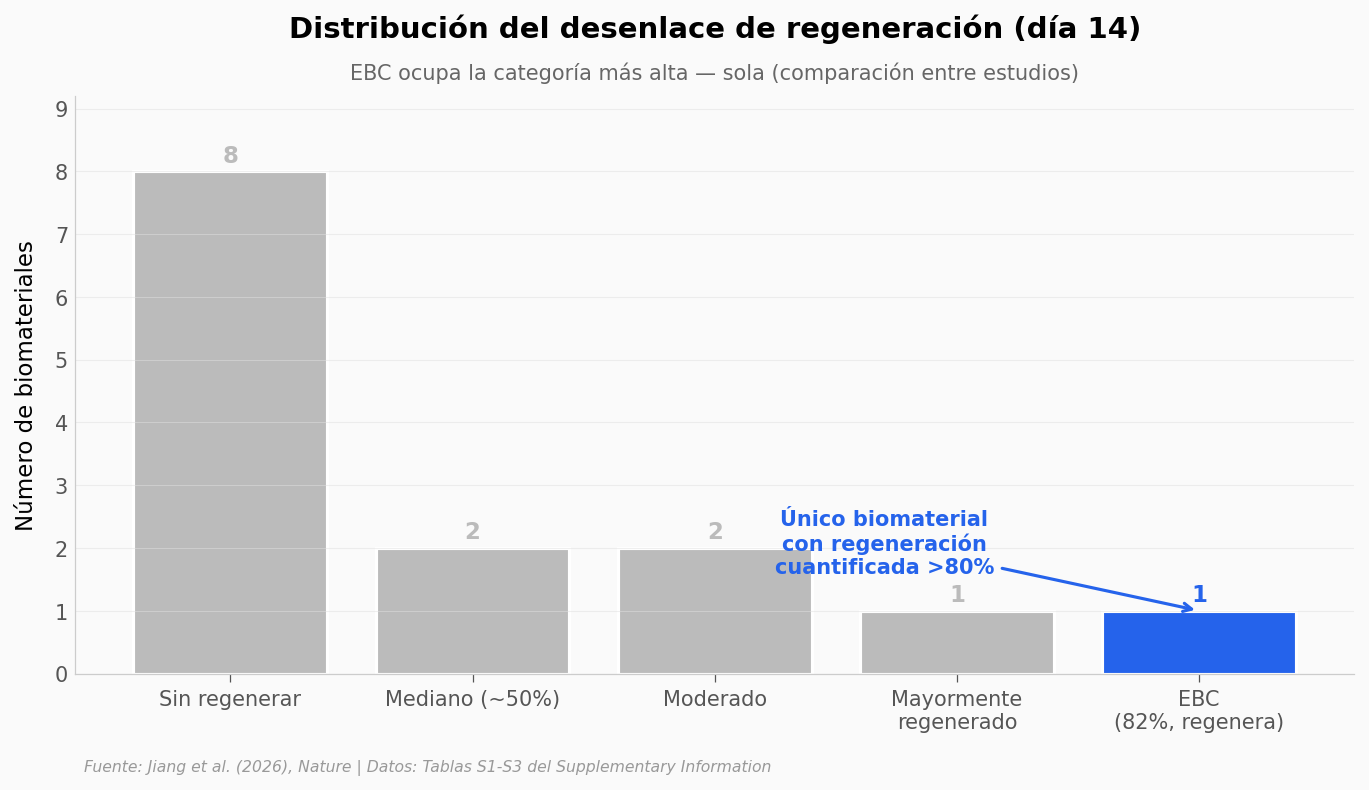

In [5]:
# Distribución cualitativa de regeneración entre los 14 biomateriales
# Mapear el outcome a una categoría ordinal
outcome_map = {
    'Largely unregenerated': 1,
    'Around 50% (Day 30)': 2,
    'Moderately regenerated': 3,
    'Largely regenerated': 4,
    '82% (largely regenerated)': 5,    # EBC
    '51%': 2,                            # Floseal
}
b2 = biomats.copy()
b2['outcome_score'] = b2['regeneration_outcome_day14'].map(outcome_map)

fig, ax = plt.subplots(figsize=(11, 5))

# Counts por categoría
score_counts = b2['outcome_score'].value_counts().sort_index()
score_labels = {
    1: 'Sin regenerar',
    2: 'Mediano (~50%)',
    3: 'Moderado',
    4: 'Mayormente\nregenerado',
    5: 'EBC\n(82%, regenera)',
}
positions = list(score_counts.index)
heights = [score_counts.get(p, 0) for p in positions]
labels = [score_labels[p] for p in positions]

# EBC se pinta distinto
bar_colors = [COLOR_EBC if p == 5 else '#BBBBBB' for p in positions]
bars = ax.bar(range(len(positions)), heights, color=bar_colors,
              edgecolor='white', linewidth=1.5)

for i, h in enumerate(heights):
    ax.text(i, h + 0.15, str(h), ha='center', fontsize=11, fontweight='bold',
            color=bar_colors[i])

ax.set_xticks(range(len(positions)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Número de biomateriales', fontsize=11)
ax.set_yticks(range(0, max(heights)+2))
ax.set_ylim(0, max(heights) + 1.2)

ax.set_title('Distribución del desenlace de regeneración (día 14)',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'EBC ocupa la categoría más alta — sola (comparación entre estudios)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Flecha que apunta al EBC
ebc_idx = positions.index(5) if 5 in positions else None
if ebc_idx is not None:
    ax.annotate('Único biomaterial\ncon regeneración\ncuantificada >80%',
                xy=(ebc_idx, heights[ebc_idx]),
                xytext=(ebc_idx - 1.3, heights[ebc_idx] + 0.6),
                fontsize=10, color=COLOR_EBC, fontweight='bold',
                ha='center',
                arrowprops=dict(arrowstyle='->', color=COLOR_EBC, lw=1.5))

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_outcome.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| EBC regenera 78% del tejido hepático en día 5, vs 20% del Floseal | ⚠️ | Soportada por la Tabla S3, pero con n=1 por celda (estimación de imágenes histológicas, sin SD). El paper no reporta réplicas cuantitativas |
| El gap inicial de 58 puntos porcentuales se reduce a 16 pp en día 28 | ✅ | Cálculo directo desde los seis valores de la Tabla S3 (78-20=58, 100-84=16) |
| El polímero HA-TZ se degrada de 2.38M a 257k g/mol en 60 min con hialuronidasa | ✅ | Tabla S2, valores reportados directamente |
| EBC es el único de 14 biomateriales con respuesta de cuerpo extraño "mínima" | ✅ | Tabla S3 cualitativa: 1 "Minimal", 6 "Yes", 7 "N/A" |
| EBC tiene 13× más resistencia a fractura y 4× más adhesión que un coágulo nativo | ⚠️ | Reportado en el abstract; los datos brutos están en figuras paywalled, no en las tablas suplementarias accesibles |

> **Limitaciones del dataset:**
> - La Tabla S3 reporta un único valor por (biomaterial × día); los autores la generan de imágenes histológicas, sin SD ni n por celda.
> - Los headlines mecánicos (13×, 4×) vienen del abstract — los puntos individuales están en figuras del paper, no en tablas.
> - Estudio en rata (in vivo) y mezcla ex vivo de glóbulos rojos humanos y porcinos. La traducción clínica a humanos requiere ensayos adicionales.
> - El paper compara con 13 biomateriales reportados en otros estudios — las condiciones experimentales no son idénticas entre referencias.

## Ahora tú

1. **¿Cuál es el "punto de cruce" donde EBC y Floseal se acercan?** Pista: prueba con `liver.pivot(index='day', columns='biomaterial', values='regeneration_pct').diff(axis=1)` y mira cómo cae el gap absoluto.

2. **¿Qué tan rápido cae el polímero (constante de decaimiento)?** Pista: ajusta una exponencial `Mw(t) = Mw₀ · exp(-k·t)` a los 4 puntos de `polymer_mw` con `scipy.optimize.curve_fit`.

3. **¿Cómo cambiaría la lectura si supiéramos la varianza?** Modifica `DIA_FOCO` arriba al 14 o al 28 — ¿qué pasa si el gap real fuera ±10 pp?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Constante de decaimiento del polímero (ajuste exponencial simple)
from scipy.optimize import curve_fit

def exp_decay(t, mw0, k):
    return mw0 * np.exp(-k * t)

t = polymer_mw.hyaluronidase_min.values
y = polymer_mw.mw_g_per_mol.values

popt, _ = curve_fit(exp_decay, t, y, p0=[y[0], 0.05])
mw0_fit, k_fit = popt
half_life = np.log(2) / k_fit

# Ajuste exponencial — pero verificar bondad de ajuste
residuals = y - exp_decay(t, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot
rel_resid_pct = (residuals / y * 100)

print(f"Ajuste Mw(t) = {mw0_fit/1e6:.2f}M × exp(-{k_fit:.4f} · t)")
print(f"R² = {r2:.3f}  (n=4 puntos — pocos para ajuste robusto)")
print(f"Residuales relativos por punto: {[f'{r:+.0f}%' for r in rel_resid_pct]}")
print(f"Predicción a 60 min: {exp_decay(60, *popt)/1000:.0f}k  vs observado: {y[-1]/1000:.0f}k")
print()
print("Interpretación: el decaimiento NO sigue una exponencial limpia en este")
print("rango (residual de +73% en t=60). Reportamos la pendiente inicial como")
print(f"orden de magnitud — el Mw cae ~{y[0]/y[-1]:.1f}x en 60 min — pero la")
print("vida media de 12 min es una extrapolación, no una constante medida.")

Ajuste Mw(t) = 2.36M × exp(-0.0591 · t)
R² = 0.974  (n=4 puntos — pocos para ajuste robusto)
Residuales relativos por punto: ['+1%', '-24%', '+39%', '+73%']
Predicción a 60 min: 68k  vs observado: 257k

Interpretación: el decaimiento NO sigue una exponencial limpia en este
rango (residual de +73% en t=60). Reportamos la pendiente inicial como
orden de magnitud — el Mw cae ~9.3x en 60 min — pero la
vida media de 12 min es una extrapolación, no una constante medida.


## Fuentes

**Paper**: [Engineering tough blood clots for rapid haemostasis and enhanced regeneration](https://doi.org/10.1038/s41586-026-10412-y)  
*Nature, 2026-04-29*

**Supplementary Material**: [Suppl Figs 1-19, Tables S1-S3 (MOESM1)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10412-y/MediaObjects/41586_2026_10412_MOESM1_ESM.pdf)  
*Mismo DOI editorial. Tablas S1/S2/S3 transcritas visualmente del PDF.*

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible publicado en [el Lab de Ciencia a Mordiscos](https://cienciaamordiscos.com). Código bajo licencia MIT, datos transcritos del Supplementary Information del paper original (acceso público).*